# 01 - Data Preprocessing Pipeline


##  Khởi tạo SparkSession

In [1]:
from pyspark.sql import SparkSession
import warnings, sys, time
warnings.filterwarnings("ignore")

spark = SparkSession.builder \
    .appName("eCommerce_Preprocessing") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.default.parallelism", "4") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark  : {spark.version}")
print(f"Python : {sys.version.split()[0]}")

## Đọc dữ liệu

In [2]:

DATA_PATH = "/home/jovyan/work/data/kz.csv"

t0 = time.time()
df_raw = spark.read.csv(DATA_PATH, header=True, inferSchema=True)

total_rows = df_raw.count()
print(f"Số dòng       : {total_rows:,}")
print(f"Số cột        : {len(df_raw.columns)}")
print(f"\nTên cột: {df_raw.columns}")

df_raw.printSchema()
df_raw.show(5, truncate=False)

Số dòng       : 2,633,521
Số cột        : 8

Tên cột: ['event_time', 'order_id', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id']
root
 |-- event_time: timestamp (nullable = true)
 |-- order_id: long (nullable = true)
 |-- product_id: long (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: long (nullable = true)

+-------------------+-------------------+-------------------+-------------------+---------------------------+-------+------+-------------------+
|event_time         |order_id           |product_id         |category_id        |category_code              |brand  |price |user_id            |
+-------------------+-------------------+-------------------+-------------------+---------------------------+-------+------+-------------------+
|2020-04-24 11:50:39|2294359932054536986|1515966223509089906|2268105426648170900|el

## Kiểm tra tổng quan dữ liệu (EDA)

In [ ]:
from pyspark.sql.functions import (
    col, count, when, isnull, round as _round,
    avg, stddev, percentile_approx, desc, countDistinct,
    to_timestamp, min as _min, max as _max, sum as _sum
)

# ── NULL từng cột ─────────────────────────────────────────────────
print(f"{'Cột':<20} {'NULL':>10} {'Tỷ lệ %':>10}")
print("-" * 42)
for c in df_raw.columns:
    n   = df_raw.filter(isnull(col(c))).count()
    pct = n / total_rows * 100
    print(f"{c:<20} {n:>10,} {pct:>9.1f}%")

# ── Duplicate theo order_id ───────────────────────────────────────
dup = df_raw.groupBy("order_id") \
    .agg(count("*").alias("cnt")) \
    .filter(col("cnt") > 1).count()
print(f"\norder_id trùng : {dup:,}")

# ── Thống kê price ────────────────────────────────────────────────
print("\n=== Thống kê price ===")
df_raw.filter(col("price") > 0).select(
    _round(avg("price"),    2).alias("trung_binh"),
    _round(stddev("price"), 2).alias("do_lech_chuan"),
    _round(percentile_approx("price", 0.25), 2).alias("Q1"),
    _round(percentile_approx("price", 0.50), 2).alias("median"),
    _round(percentile_approx("price", 0.75), 2).alias("Q3"),
    _round(percentile_approx("price", 0.99), 2).alias("P99"),
).show()

# ── Giá bất thường ───────────────────────────────────────────────
gia_bt = df_raw.select(
    _sum(when(col("price") == 0,    1).otherwise(0)).alias("gia_bang_0"),
    _sum(when(col("price") <  0,    1).otherwise(0)).alias("gia_am"),
    _sum(when(col("price").isNull(),1).otherwise(0)).alias("gia_null"),
    _sum(when(col("price") > 10000, 1).otherwise(0)).alias("gia_tren_10k"),
).collect()[0]

print("=== Giá bất thường ===")
print(f"  Giá = 0     : {gia_bt['gia_bang_0']:,}")
print(f"  Giá âm      : {gia_bt['gia_am']:,}")
print(f"  Giá NULL    : {gia_bt['gia_null']:,}")
print(f"  Giá > 10000 : {gia_bt['gia_tren_10k']:,}")

# ── Khoảng thời gian ─────────────────────────────────────────────
df_t  = df_raw.withColumn("ts", to_timestamp("event_time"))
tr    = df_t.agg(_min("ts").alias("start"),
                  _max("ts").alias("end")).collect()[0]
print(f"\nKhoảng TG : {tr['start']}  →  {tr['end']}")

# ── Unique counts ────────────────────────────────────────────────
print("\n=== Unique counts ===")
df_raw.agg(
    countDistinct("user_id").alias("khach_co_tk"),
    countDistinct("order_id").alias("don_hang"),
    countDistinct("product_id").alias("san_pham"),
    countDistinct("brand").alias("thuong_hieu"),
    countDistinct("category_code").alias("danh_muc"),
).show()

Cột                        NULL    Tỷ lệ %
------------------------------------------
event_time                    0       0.0%
order_id                      0       0.0%
product_id                    0       0.0%
category_id             431,954      16.4%
category_code           612,202      23.2%
brand                   506,005      19.2%
price                   431,954      16.4%
user_id               2,069,352      78.6%

order_id trùng : 563,515

=== Thống kê price ===
+----------+-------------+-----+------+------+-------+
|trung_binh|do_lech_chuan|   Q1|median|    Q3|    P99|
+----------+-------------+-----+------+------+-------+
|     154.1|       241.95|14.56| 55.53|196.74|1157.38|
+----------+-------------+-----+------+------+-------+

=== Giá bất thường ===


In [8]:
# Xem thử order_id trùng trông như thế nào
df_raw.groupBy("order_id") \
    .agg(count("*").alias("cnt")) \
    .filter(col("cnt") > 1) \
    .orderBy(desc("cnt")) \
    .show(10, truncate=False)

+-------------------+---+
|order_id           |cnt|
+-------------------+---+
|2388440981134393883|61 |
|2388440981134689974|53 |
|2348791291912913068|48 |
|2353219851624907454|39 |
|2348807739909603922|36 |
|2348774045262021596|35 |
|2348781353710912154|33 |
|2388440981134684810|33 |
|2319266497744077025|33 |
|2388203803871543730|32 |
+-------------------+---+
only showing top 10 rows



In [9]:
# Xem thử order_id bị trùng nhiều nhất trông như thế nào
df_raw.filter(col("order_id") == "2388440981134393883") \
    .show(10, truncate=False)

+-------------------+-------------------+-------------------+-------------------+------------------------------+-------+------+-------+
|event_time         |order_id           |product_id         |category_id        |category_code                 |brand  |price |user_id|
+-------------------+-------------------+-------------------+-------------------+------------------------------+-------+------+-------+
|2020-09-02 18:49:11|2388440981134393883|1515966223510557635|2268105443391832826|NULL                          |wilmax |12.01 |NULL   |
|2020-09-02 18:49:11|2388440981134393883|1515966223510331444|2268105444734010134|furniture.living_room.shelving|inhouse|17.34 |NULL   |
|2020-09-02 18:49:11|2388440981134393883|1515966223509616442|2268105404569355178|NULL                          |braun  |486.09|NULL   |
|2020-09-02 18:49:11|2388440981134393883|1515966223510879420|2268105443777708802|NULL                          |NULL   |5.76  |NULL   |
|2020-09-02 18:49:11|2388440981134393883|1515966

In [4]:
# ── 3.7 Top brand & category ──────────────────────────────────────
print("=== Top 10 thương hiệu ===")
df_raw.filter(col("brand").isNotNull() & (col("brand") != "")) \
    .groupBy("brand").agg(count("*").alias("so_lan")) \
    .orderBy(desc("so_lan")).show(10)

print("=== Top 10 danh mục ===")
df_raw.filter(col("category_code").isNotNull()) \
    .groupBy("category_code").agg(count("*").alias("so_lan")) \
    .orderBy(desc("so_lan")).show(10, truncate=False)

=== Top 10 thương hiệu ===


+-------+------+
|  brand|so_lan|
+-------+------+
|samsung|358928|
|    ava|118161|
|  tefal| 78653|
|  apple| 74709|
| huawei| 57438|
|     lg| 55685|
|philips| 52327|
|    neo| 42638|
|polaris| 40663|
|   oppo| 36445|
+-------+------+
only showing top 10 rows

=== Top 10 danh mục ===
+--------------------------------+------+
|category_code                   |so_lan|
+--------------------------------+------+
|electronics.smartphone          |357682|
|appliances.kitchen.refrigerators|77386 |
|16.18                           |72969 |
|electronics.video.tv            |71711 |
|computers.notebook              |71436 |
|appliances.environment.vacuum   |66471 |
|electronics.audio.headphone     |66159 |
|appliances.kitchen.kettle       |62719 |
|appliances.kitchen.washer       |56255 |
|furniture.kitchen.table         |55725 |
+--------------------------------+------+
only showing top 10 rows



## Biểu đồ trước khi xử lí

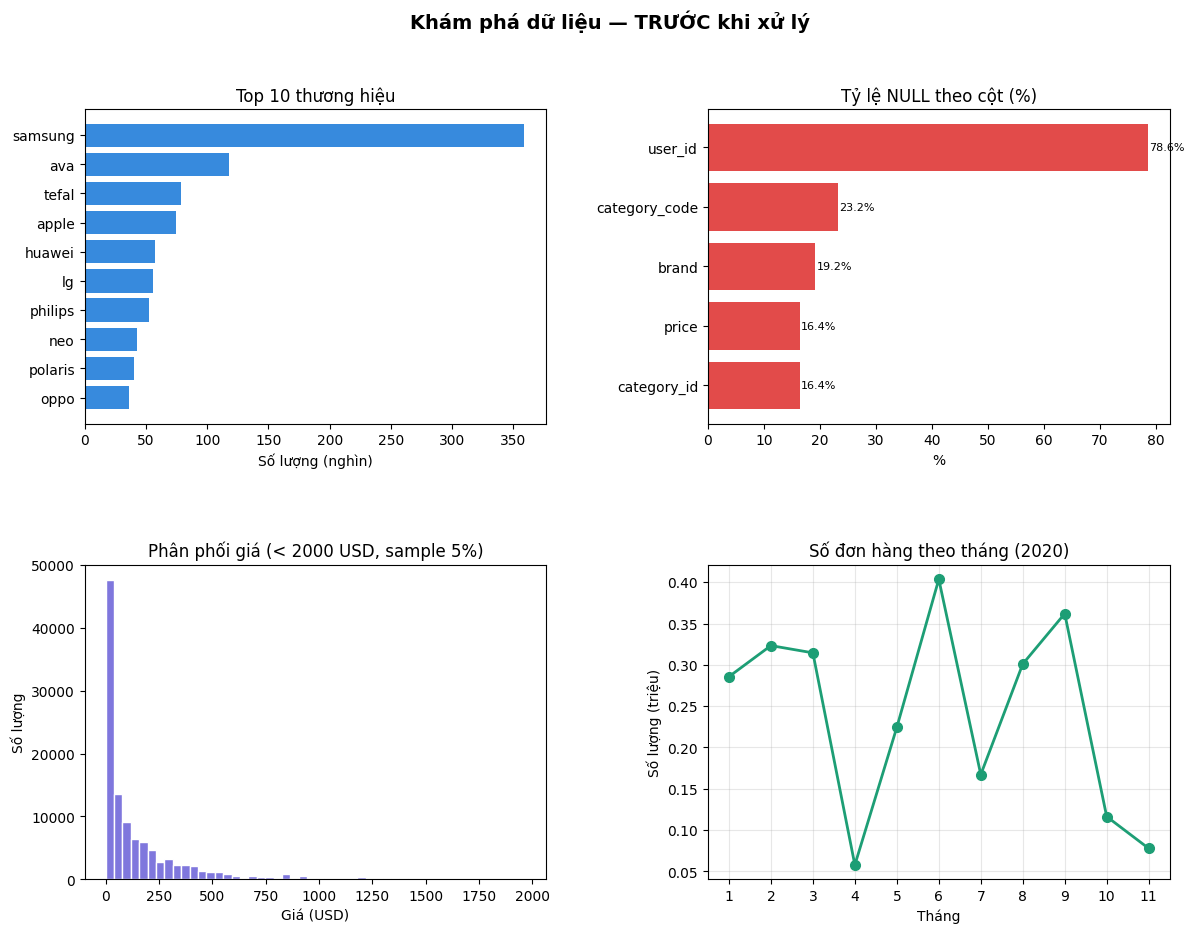

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Khám phá dữ liệu — TRƯỚC khi xử lý", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Biểu đồ 1: Top 10 brand ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
brand_pd = df_raw.filter(col("brand").isNotNull() & (col("brand") != "")) \
    .groupBy("brand").count().orderBy(desc("count")).limit(10).toPandas()
ax1.barh(brand_pd["brand"][::-1], brand_pd["count"][::-1] / 1e3,
         color="#378ADD")
ax1.set_title("Top 10 thương hiệu")
ax1.set_xlabel("Số lượng (nghìn)")

# ── Biểu đồ 2: Tỷ lệ NULL theo cột ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
import pandas as pd
null_pd = pd.DataFrame({
    "col": df_raw.columns,
    "pct": [
        df_raw.filter(isnull(col(c))).count() / total_rows * 100
        for c in df_raw.columns
    ]
}).query("pct > 0").sort_values("pct")
ax2.barh(null_pd["col"], null_pd["pct"], color="#E24B4A")
ax2.set_title("Tỷ lệ NULL theo cột (%)")
ax2.set_xlabel("%")
for i, v in enumerate(null_pd["pct"]):
    ax2.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=8)

# ── Biểu đồ 3: Phân phối giá ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
price_pd = df_raw.filter((col("price") > 0) & (col("price") < 2000)) \
    .select("price").sample(0.05).toPandas()
ax3.hist(price_pd["price"], bins=50, color="#7F77DD", edgecolor="white")
ax3.set_title("Phân phối giá (< 2000 USD, sample 5%)")
ax3.set_xlabel("Giá (USD)")
ax3.set_ylabel("Số lượng")

# ── Biểu đồ 4: Đơn hàng theo tháng ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
from pyspark.sql.functions import year, month
monthly_pd = df_raw \
    .withColumn("ts", to_timestamp("event_time")) \
    .withColumn("thang", month("ts")) \
    .groupBy("thang").count() \
    .orderBy("thang").toPandas()
ax4.plot(monthly_pd["thang"], monthly_pd["count"] / 1e6,
         "o-", color="#1D9E75", linewidth=2, markersize=7)
ax4.set_title("Số đơn hàng theo tháng (2020)")
ax4.set_xlabel("Tháng")
ax4.set_ylabel("Số lượng (triệu)")
ax4.set_xticks(monthly_pd["thang"])
ax4.grid(True, alpha=0.3)

plt.savefig("/home/jovyan/work/data/chart_before.png", dpi=120, bbox_inches="tight")
plt.show()

## Làm sạch: Duplicate + NULL + Kiểu dữ liệu + Cột mới

In [11]:
from pyspark.sql.functions import (
    col, when, isnull, lit,
    to_timestamp, to_date, year, month,
    lower, trim, regexp_replace, split
)

# ── Bước 1: Xóa duplicate toàn bộ cột ───────────────────────────
df1 = df_raw.dropDuplicates()
print(f"Sau dropDuplicates : {df1.count():,}")

# ── Bước 2: Chuyển kiểu dữ liệu ─────────────────────────────────
df2 = df1 \
    .withColumn("event_time",   to_timestamp(col("event_time"))) \
    .withColumn("price",        col("price").cast("double")) \
    .withColumn("user_id",      col("user_id").cast("string")) \
    .withColumn("order_id",     col("order_id").cast("string")) \
    .withColumn("product_id",   col("product_id").cast("string")) \
    .withColumn("category_id",  col("category_id").cast("string")) \
    .withColumn("brand",        col("brand").cast("string")) \
    .withColumn("category_code",col("category_code").cast("string"))

# ── Bước 3: Lọc dòng bắt buộc ───────────────────────────────────
df3 = df2 \
    .filter(col("event_time").isNotNull()) \
    .filter(col("price") > 0)

# ── Bước 4: Xử lý NULL từng cột ─────────────────────────────────
df4 = df3 \
    .withColumn("brand",
        when(isnull(col("brand")) | (trim(col("brand")) == ""),
             lit("unknown"))
        .otherwise(col("brand"))) \
    .withColumn("category_code",
        when(isnull(col("category_code")) | (trim(col("category_code")) == ""),
             lit("unknown"))
        .otherwise(col("category_code"))) \
    .withColumn("category_id",
        when(isnull(col("category_id")),
             lit("0"))
        .otherwise(col("category_id")))
    # user_id: giữ nguyên NULL — có ý nghĩa (khách vãng lai)

# ── Bước 5: Chuẩn hóa chuỗi ─────────────────────────────────────
df5 = df4 \
    .withColumn("brand",
        lower(trim(regexp_replace(
            col("brand"), "[^a-zA-Z0-9 ]", "")))) \
    .withColumn("category_code",
        lower(trim(regexp_replace(
            col("category_code"), r"[^a-zA-Z0-9._]", ""))))

# ── Bước 6: Tạo cột mới ──────────────────────────────────────────
df_clean = df5 \
    .withColumn("date",  to_date(col("event_time"))) \
    .withColumn("year",  year(col("event_time"))) \
    .withColumn("month", month(col("event_time"))) \
    .withColumn("category_lv1",
        when(col("category_code") != "unknown",
             split(col("category_code"), r"\.").getItem(0))
        .otherwise(lit("unknown"))) \
    .withColumn("category_lv2",
        when(col("category_code") != "unknown",
             split(col("category_code"), r"\.").getItem(1))
        .otherwise(lit("unknown")))

rows_clean = df_clean.count()

print("=" * 55)
print("  KẾT QUẢ LÀM SẠCH")
print("=" * 55)
print(f"  Tổng ban đầu              : {total_rows:,}")
print(f"  Sau dropDuplicates        : {df1.count():,}")
print(f"  Sau lọc price & time      : {rows_clean:,}")
print(f"  Tổng loại bỏ              : {total_rows-rows_clean:,} ({(total_rows-rows_clean)/total_rows*100:.1f}%)")
print("-" * 55)
print("  Xử lý NULL:")
print(f"  brand NULL        → 'unknown'  ({df3.filter(isnull('brand')).count():,} dòng)")
print(f"  category_code NULL→ 'unknown'  ({df3.filter(isnull('category_code')).count():,} dòng)")
print(f"  category_id NULL  → '0'        ({df3.filter(isnull('category_id')).count():,} dòng)")
print(f"  user_id NULL      → giữ NULL   ({df3.filter(isnull('user_id')).count():,} dòng = khách vãng lai)")
print(f"  price NULL/<=0    → xóa dòng")
print("=" * 55)

# Kiểm tra sau làm sạch — không còn NULL ở các cột đã xử lý
print("\n=== Kiểm tra NULL sau làm sạch ===")
for c in ["brand", "category_code", "category_id", "price", "event_time"]:
    n = df_clean.filter(isnull(col(c))).count()
    print(f"  {c:<20}: {n:,} NULL {'✓' if n == 0 else '← còn NULL!'}")

n_user = df_clean.filter(isnull(col("user_id"))).count()
print(f"  {'user_id':<20}: {n_user:,} NULL (khách vãng lai)")

Sau dropDuplicates : 2,632,846
  KẾT QUẢ LÀM SẠCH
  Tổng ban đầu              : 2,633,521
  Sau dropDuplicates        : 2,632,846
  Sau lọc price & time      : 2,200,772
  Tổng loại bỏ              : 432,749 (16.4%)
-------------------------------------------------------
  Xử lý NULL:
  brand NULL        → 'unknown'  (112,614 dòng)
  category_code NULL→ 'unknown'  (611,966 dòng)
  category_id NULL  → '0'        (0 dòng)
  user_id NULL      → giữ NULL   (1,637,316 dòng = khách vãng lai)
  price NULL/<=0    → xóa dòng

=== Kiểm tra NULL sau làm sạch ===
  brand               : 0 NULL ✓
  category_code       : 0 NULL ✓
  category_id         : 0 NULL ✓
  price               : 0 NULL ✓
  event_time          : 0 NULL ✓
  user_id             : 1,637,316 NULL (khách vãng lai)


In [14]:
# Luồng 1: Toàn bộ — dùng cho phân tích brand/category
# (notebook 03_brand_clustering.ipynb)
print(f"df_clean (brand analysis) : {df_clean.count():,} dòng")

# Luồng 2: Chỉ khách có tài khoản — dùng cho RFM
# (notebook 02_rfm_clustering.ipynb)
df_rfm = df_clean.filter(col("user_id").isNotNull())
print(f"df_rfm  (RFM clustering)  : {df_rfm.count():,} dòng")
print(f"\nKhách vãng lai")
print(f"  không thể theo dõi hành vi theo thời gian")

df_clean (brand analysis) : 2,200,772 dòng
df_rfm  (RFM clustering)  : 563,456 dòng

Khách vãng lai
  không thể theo dõi hành vi theo thời gian


In [15]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import datediff, sum as _sum, max as _max

SNAPSHOT = "2020-12-01"

# Tính RFM để demo pipeline
rfm_demo = df_rfm.groupBy("user_id").agg(
    datediff(lit(SNAPSHOT), _max("date")).alias("recency"),
    count("*").alias("frequency"),
    _round(_sum("price"), 2).alias("monetary")
).filter(col("monetary") > 0)

# Pipeline: Assemble → Scale
assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"],
    outputCol="features_raw"
)
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True, withMean=True
)

pipeline       = Pipeline(stages=[assembler, scaler])
pipeline_model = pipeline.fit(rfm_demo)
rfm_scaled     = pipeline_model.transform(rfm_demo)

print("=== ML Pipeline (5 dòng mẫu) ===")
rfm_scaled.select(
    "user_id","recency","frequency","monetary","features_scaled"
).show(5, truncate=False)
print("ML Pipeline OK!")

=== ML Pipeline (5 dòng mẫu) ===
+-------------------+-------+---------+--------+---------------------------------------------------------------+
|user_id            |recency|frequency|monetary|features_scaled                                                |
+-------------------+-------+---------+--------+---------------------------------------------------------------+
|1515915625448766480|130    |6        |3028.1  |[0.012907603047688421,1.0623222591837447,2.423275306347056]    |
|1515915625443027224|189    |2        |684.9   |[0.10818185253240155,-0.1212359425598741,0.17541407590277086]  |
|1515915625452334085|215    |4        |40.9    |[0.1501671150171904,0.4705431583119353,-0.4423832236901446]    |
|1515915625442940349|165    |169      |15508.37|[0.0694262256233657,49.29231898023622,14.395755281798104]      |
|1515915625451520334|116    |6        |112.82  |[-0.009699845982582493,1.0623222591837447,-0.37338946315175564]|
+-------------------+-------+---------+--------+---------------

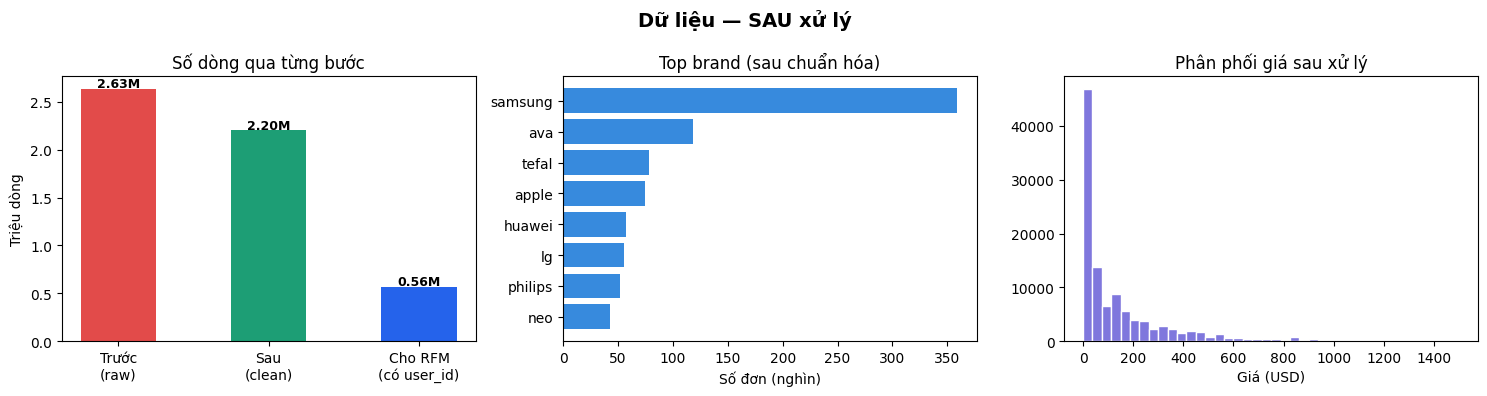

In [ ]:
fig2, axes = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle("Dữ liệu — SAU xử lý", fontsize=14, fontweight="bold")

# ── 1. Trước vs Sau ──────────────────────────────────────────────
bars = axes[0].bar(
    ["Trước\n(raw)", "Sau\n(clean)", "Cho RFM\n(có user_id)"],
    [total_rows/1e6, rows_clean/1e6, df_rfm.count()/1e6],
    color=["#E24B4A", "#1D9E75", "#2563EB"], width=0.5
)
axes[0].set_title("Số dòng qua từng bước")
axes[0].set_ylabel("Triệu dòng")
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.2f}M",
        ha="center", fontsize=9, fontweight="bold"
    )

# ── 2. Top brand sau clean ───────────────────────────────────────
brand_clean = df_clean \
    .filter(col("brand") != "unknown") \
    .groupBy("brand").count() \
    .orderBy(desc("count")).limit(8).toPandas()
axes[1].barh(brand_clean["brand"][::-1],
             brand_clean["count"][::-1] / 1e3,
             color="#378ADD")
axes[1].set_title("Top brand (sau chuẩn hóa)")
axes[1].set_xlabel("Số đơn (nghìn)")

# ── 3. Phân phối price sau clean ─────────────────────────────────
price_clean = df_clean \
    .filter(col("price") < 1500) \
    .select("price").sample(0.05).toPandas()
axes[2].hist(price_clean["price"], bins=40,
             color="#7F77DD", edgecolor="white")
axes[2].set_title("Phân phối giá sau xử lý")
axes[2].set_xlabel("Giá (USD)")

plt.tight_layout()
plt.savefig("/home/jovyan/work/data/chart_after.png",
            dpi=120, bbox_inches="tight")
plt.show()

In [1]:
OUT_CLEAN = "/home/jovyan/work/data/clean_data/"
OUT_RFM   = "/home/jovyan/work/data/rfm_input/"

t0 = time.time()
df_clean.write.mode("overwrite") \
    .partitionBy("year", "month") \
    .parquet(OUT_CLEAN)
print(f"df_clean → {OUT_CLEAN}  ({time.time()-t0:.1f}s)")

df_rfm = df_clean.filter(col("user_id").isNotNull())

t0 = time.time()
df_rfm.write.mode("overwrite").parquet(OUT_RFM)
print(f"df_rfm   → {OUT_RFM}  ({time.time()-t0:.1f}s)")

NameError: name 'time' is not defined